In [1]:
import os
import numpy as np
import torch

from sensorium.utility import get_data, set_random_seed

from utils import load_model_from_config, get_knn_curve, get_ari_curve
import matplotlib.pyplot as plt

random_seed = 42
set_random_seed(random_seed, deterministic=False)

device = 'cuda:7'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"
# as filenames, we'll select all 7 datasets

filenames = [] 
for file in [
    'static23343-5-17-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static23964-4-22-GrayImageNet-94c6ff995dac583098847cfecd43e7b6',
    'static23656-14-22-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static21067-10-18-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static26872-17-20-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static22846-10-16-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static27204-5-13-GrayImageNet-94c6ff995dac583098847cfecd43e7b6',
]:
    filenames.append(os.path.join(basepath, file))

dataset_fn = "sensorium.datasets.static_loaders"

dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "exclude_eye_position_paths": [
        '/srv/user/polina/sensorium/sensorium/notebooks/data/static26872-17-20-GrayImageNet-94c6ff995dac583098847cfecd43e7b6'
    ],
    "batch_size": 128,
    "scale": 0.25,
}
dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

In [2]:
# load models
paths = [
    '../training/runs/baseline/baseline_seed9',
    '../training/runs/baseline/baseline_seed87',
    '../training/runs/baseline/baseline_seed333',
]

models = []
for path in paths:
    model = load_model_from_config(path, dataloaders, device)
    models.append(model)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [3]:
model = models[0]

# whitening

In [4]:
# load batches and save feature vecs
num_batches = 5

features = {}
for mode in ['train', 'validation']:
    mode_features = []
    for key in data_keys:
        batch_features = []
        for i, batch in enumerate(dataloaders[mode][key]):
            if i == num_batches:
                break

            img, target, behav = batch[:3]
            img = img.to(device)
            
            if len(batch) == 4:
                pupil = batch[3]
                pupil = pupil.to(device)
            elif len(batch) == 3:
                pupil = None

            pred, feature = model(img, data_key=key, pupil_center=pupil, return_vec=True)
            feature = feature.detach().cpu()
            batch_features.append(feature)
        mode_features.append(torch.cat(batch_features))

    flattened = torch.cat([f.flatten(0, 1) for f in mode_features])
    features[mode] = flattened

In [5]:
# helper for mu, cov and corr computation
def get_stats(X):
    mu = X.mean(0, keepdim=True)
    Xc = X - mu
    cov = Xc.T @ Xc / (X.shape[0] - 1)
    std = cov.diag().sqrt()
    cor = cov / torch.outer(std, std)
    return mu, cov, cor

In [ ]:
# whiten
train_mu, train_cov, train_cor = get_stats(features['train'])

eye = torch.eye(train_cov.shape[0])
L = torch.linalg.cholesky(train_cov + 1e-5 * eye)
W = torch.linalg.inv(L).T

X = features['validation']
Xw = (X - train_mu) @ W

white_mu, white_cov, white_cor = get_stats(Xw)

In [31]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def plot_corr_matrices(corr1, corr2, labels=None,
                       titles=("Matrix 1", "Matrix 2"),
                       cmap="RdBu_r",
                       bins=30):

    # ------------------------------------------------------------
    # 1. Get the ordering from seaborn's clustering
    # ------------------------------------------------------------
    def get_cluster_order(corr):
        # Temporary clustermap only to obtain the ordering
        g = sns.clustermap(
            corr,
            row_cluster=True,
            col_cluster=True,
            cmap=cmap,
            xticklabels=False,
            yticklabels=False,
        )

        order = g.dendrogram_row.reordered_ind
        plt.close(g.fig)

        return order

    order = get_cluster_order(corr1)
    order1 = order
    order2 = order

    # If both matrices have the same variables, you may want
    # exactly the same ordering for direct comparison.
    # In that case, use:
    #
    # order = get_cluster_order(corr1)
    # order1 = order2 = order

    corr1_ordered = np.asarray(corr1)[np.ix_(order1, order1)]
    corr2_ordered = np.asarray(corr2)[np.ix_(order2, order2)]

    if labels is not None:
        labels1 = np.asarray(labels)[order1]
        labels2 = np.asarray(labels)[order2]
    else:
        labels1 = labels2 = None

    # ------------------------------------------------------------
    # 2. Fixed color scale centered at zero
    # ------------------------------------------------------------
    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    # ------------------------------------------------------------
    # 3. Figure
    # ------------------------------------------------------------
    fig, axes = plt.subplots(
        1, 2,
        figsize=(14, 7),
        constrained_layout=True
    )

    matrices = [corr1_ordered, corr2_ordered]
    ordered_labels = [labels1, labels2]

    # ------------------------------------------------------------
    # 4. Histogram of off-diagonal values
    #    Use the same symmetric x-limits and ticks for both
    # ------------------------------------------------------------

    # Get off-diagonal values from both matrices
    off_diag_values = []

    for matrix in matrices:
        off_diag = matrix[~np.eye(matrix.shape[0], dtype=bool)]
        off_diag_values.append(off_diag)

    # Maximum absolute off-diagonal value across BOTH matrices
    max_abs = max(
        np.max(np.abs(values))
        for values in off_diag_values
    )

    # Optional: round upward to a clean value
    xlim = np.ceil(max_abs * 10) / 10

    # Common ticks, symmetric around zero
    ticks = np.linspace(-xlim, xlim, 5)

    for ax, matrix, matrix_labels, title, off_diag in zip(
        axes,
        matrices,
        ordered_labels,
        titles,
        off_diag_values,
    ):
        # Heatmap
        sns.heatmap(
            matrix,
            ax=ax,
            cmap=cmap,
            norm=norm,
            square=True,
            xticklabels=matrix_labels if matrix_labels is not None else False,
            yticklabels=matrix_labels if matrix_labels is not None else False,
            cbar=False,
        )

        ax.set_title(title)

        # Histogram inset
        hist_ax = inset_axes(
            ax,
            width="28%",
            height="28%",
            loc="upper right",
            borderpad=1.0,
        )

        hist_ax.hist(
            off_diag,
            bins=bins,
            range=(-xlim, xlim),
            density=True,
        )

        # Same limits and ticks for both histograms
        hist_ax.set_xlim(-xlim, xlim)
        hist_ax.set_xticks(ticks)

        hist_ax.tick_params(
            axis="both",
            labelsize=7,
            length=2,
        )

        hist_ax.axvline(
            0,
            linestyle="--",
            linewidth=0.8,
        )

        hist_ax.set_facecolor("white")

    # One shared colorbar
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    fig.colorbar(
        sm,
        ax=axes,
        shrink=0.75,
        label="Correlation",
    )

    return fig, axes

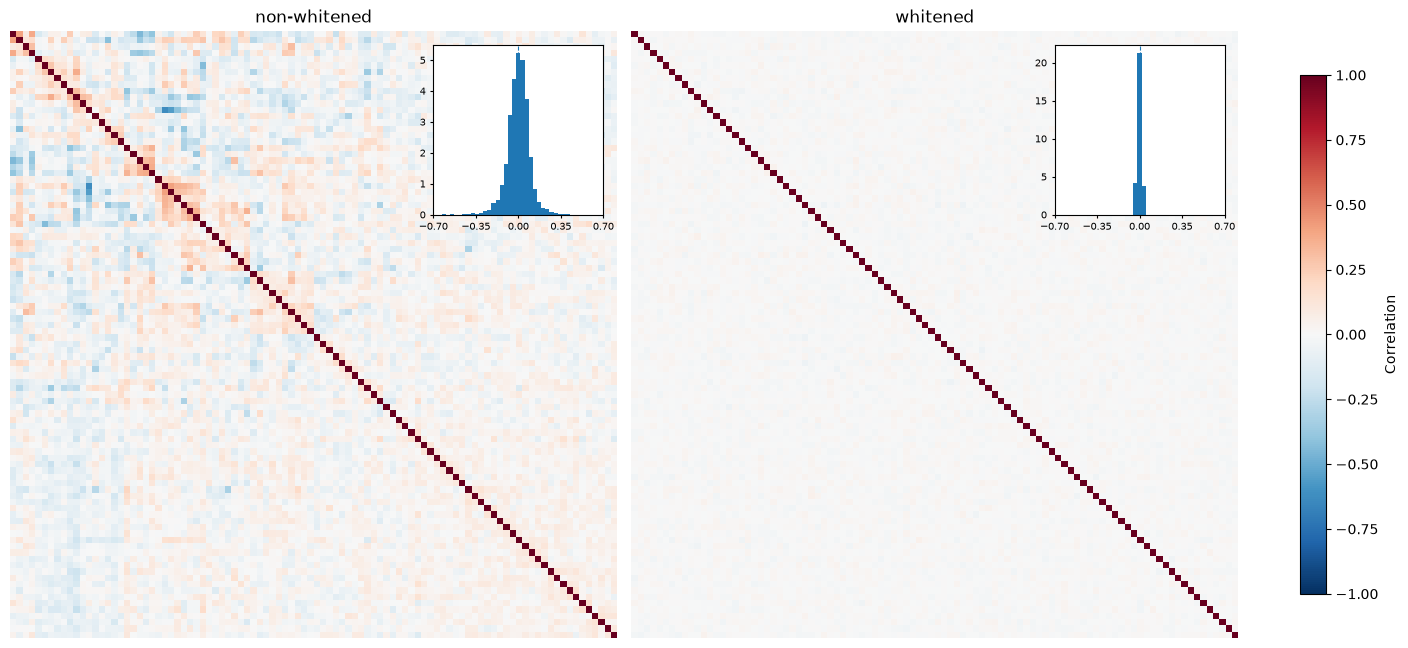

In [39]:
fig, axes = plot_corr_matrices(
    val_cor,
    white_cor,
    labels=None,
    titles=('non-whitened', 'whitened'),
    bins=41,
)
plt.show()

# rfs

In [40]:
h, w = 28, 56
base_grids = []
for model in models:
    grids = []
    for key in data_keys:
        grid = model.readout[key].sample_grid(1, sample=False).squeeze().detach().cpu()
        grid[:, 0] = (grid[:, 0] + 1) / 2 * w
        grid[:, 1] = (grid[:, 1] + 1) / 2 * h

        grids.append(grid)

    base_grids.append(grids)

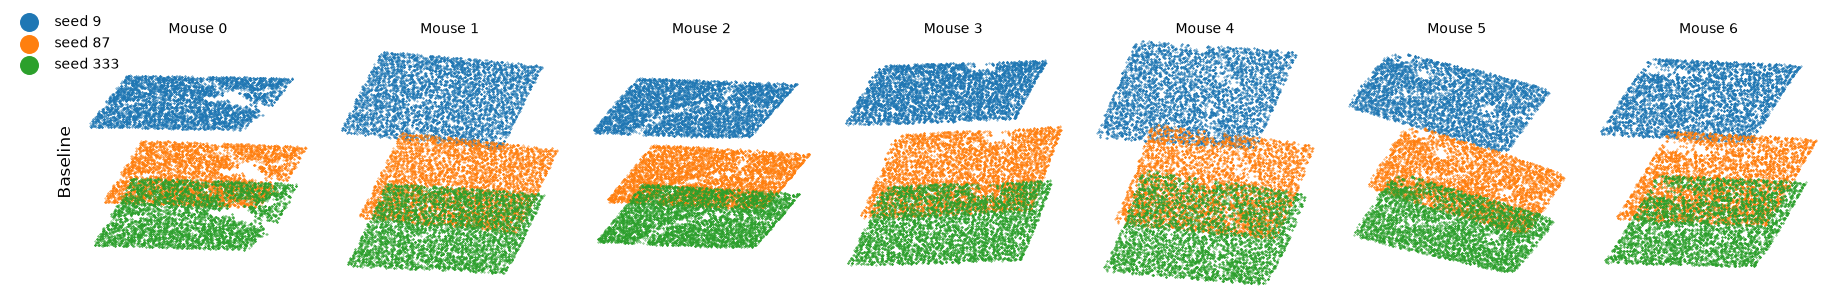

In [59]:
model_seeds = [9, 87, 333]
model_types = {
    "Baseline": base_grids,
}

num_mice = 7
num_models = len(model_seeds)

fig, axs = plt.subplots(len(model_types), num_mice, figsize=(18, 4))

for row_idx, (type_name, grids) in enumerate(model_types.items()):
    for mouse_idx in range(num_mice):
        ax = axs[row_idx, mouse_idx] if len(model_types) > 1 else axs[mouse_idx]

        for model_idx in range(num_models):
            grid = grids[model_idx][mouse_idx]
            ax.scatter(
                grid[:, 0], grid[:, 1],
                alpha=1, s=0.1,
                label=f"seed {model_seeds[model_idx]}",
            )
        ax.set_aspect('equal')

        # remove spines and ticks
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_xticks([])
        ax.set_yticks([])

        # row labels on first column only
        if mouse_idx == 0:
            ax.set_ylabel(type_name, rotation=90, size='large')


# single shared legend for seeds (bigger markers than the tiny scatter points)
handles, labels = axs[0, 0].get_legend_handles_labels() if len(model_types) > 1 else axs[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    bbox_to_anchor=(0.05, 0.9),
    markerscale=40,
    frameon=False,
)
plt.tight_layout()

# Add column titles at a fixed figure-level height 
for mouse_idx in range(num_mice): 
    ax = axs[mouse_idx] if len(model_types) == 1 else axs[0, mouse_idx] 
    bbox = ax.get_position() 
    fig.text( 
        bbox.x0 + bbox.width / 2, 
        0.85, 
        f"Mouse {mouse_idx}", 
        ha="center", 
        va="top", 
    ) 

plt.show()